<a href="https://colab.research.google.com/github/aman-verma02/Convolutional-Neural-Network/blob/main/functional-api/age_gender_using_Functional_API_(integrated_model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
jangedoo_utkface_new_path = kagglehub.dataset_download('jangedoo/utkface-new')

print('Data source import complete.')


Using Colab cache for faster access to the 'utkface-new' dataset.
Data source import complete.


In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/utkface-new/crop_part1/14_1_0_20170104005937407.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/1_0_2_20161219162626830.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/26_1_2_20170104022154229.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/10_0_0_20170110220539329.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/31_1_0_20170105162529475.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/2_0_3_20161219230609241.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/29_0_0_20170103181910385.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/36_1_0_20170109141845861.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/2_0_4_20170103205319954.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/2_1_2_20161219151919100.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/9_1_0_20170109202228755.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/72_1_3_20170109142938059.jpg.chip.jpg
/kaggle/input/utkface-new/crop_part1/75_0_0_2017011121

In [28]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [29]:
folder_path = os.path.join(jangedoo_utkface_new_path, 'UTKFace')

In [30]:
age = []
gender = []
img_path = []

for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(os.path.join(folder_path, file))

In [31]:
df = pd.DataFrame({
    'age' : age,
    'gender': gender,
    'img': img_path
})

In [32]:
train_df = df.sample(frac = 1, random_state = 0).iloc[: 20000]
test_df = df.sample(frac = 1, random_state = 0).iloc[20000:]

In [33]:
train_df.shape

(20000, 3)

In [34]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 30,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [35]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img',
    y_col=['age','gender'],
    target_size=(200,200),
    class_mode='multi_output'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img',
    y_col=['age','gender'],
    target_size=(200,200),
    class_mode='multi_output'
)

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [36]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

In [37]:
vggnet = VGG16(include_top=False, input_shape=(200,200,3))

In [38]:
vggnet.trainable=False

output = vggnet.layers[-1].output         ## Exracting last layer of output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

In [39]:
model = Model(inputs=vggnet.input,outputs=[output1,output2])

In [40]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

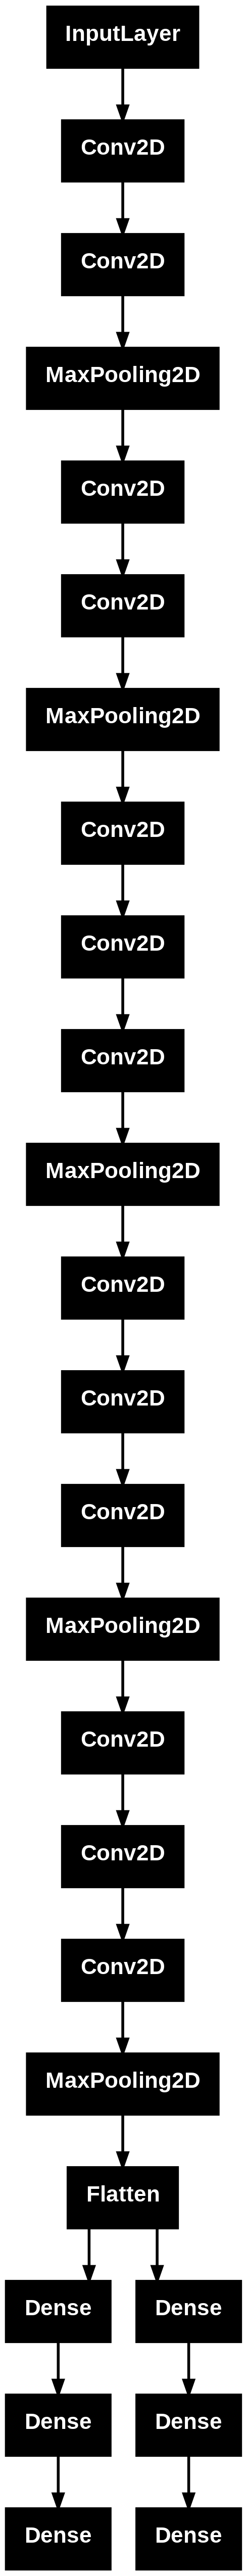

In [41]:
from keras.utils import plot_model
plot_model(model)

In [42]:
model.compile(optimizer='adam', loss={'age': 'mae', 'gender': 'binary_crossentropy'}, metrics={'age': 'mae', 'gender': 'accuracy'},loss_weights={'age':1,'gender':99})

In [43]:
def wrap_generator_output(generator):
    while True:
        x, y = next(generator)
        # 'y' from ImageDataGenerator with multi_output class_mode and list y_col
        # is typically a list of numpy arrays, e.g., [age_labels, gender_labels]
        yield x, {'age': y[0], 'gender': y[1]}

In [44]:
# model.fit(train_generator, epochs=10, validation_data=test_generator)

In [ ]:
model.fit(
    wrap_generator_output(train_generator),
    epochs=10,
    validation_data=wrap_generator_output(test_generator),
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=test_generator.samples // test_generator.batch_size
)

Epoch 1/10
  3/625 ━━━━━━━━━━━━━━━━━━━━ 2:48:41 16s/step - age_loss: 26.7288 - age_mae: 26.7288 - gender_accuracy: 0.4288 - gender_loss: 1.7814 - loss: 203.0901